# V0.7-F Green AI Evaluation

## 1. Research context

This notebook reports the Green AI evaluation for **A Lightweight and Green Blockchain-AI Framework for Secure and Energy-Efficient Supply Chain Management**. It asks whether the three feature configurations frozen by V0.6 reduce computational resource use while preserving the already-locked cybersecurity detection performance.

This is an **artifact-only reporting notebook**. It reads immutable V0.7-C/D/E outputs and existing figures. It does not load raw data, recreate attacks, select features, train models, rerun benchmarks, tune thresholds, or write into `results/`.

In [1]:
from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

def locate_repository_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'results' / 'green_evaluation').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate results/green_evaluation from the current directory.')

ROOT = locate_repository_root(Path.cwd())
RESULTS = ROOT / 'results' / 'green_evaluation'
required = {
    'energy': RESULTS / 'energy_capability.json',
    'environment': RESULTS / 'environment_metadata.json',
    'run_manifest': RESULTS / 'v07d_run_manifest.json',
    'v07d_governance': RESULTS / 'v07d_governance_audit.json',
    'observations': RESULTS / 'computational_observations.csv',
    'seed_summaries': RESULTS / 'v07e_seed_summaries.csv',
    'performance_efficiency': RESULTS / 'v07e_performance_efficiency.csv',
    'paired_comparisons': RESULTS / 'v07e_paired_comparisons.csv',
    'efficiency_summary': RESULTS / 'v07e_efficiency_summary.csv',
    'variability': RESULTS / 'v07e_variability_analysis.csv',
    'pareto': RESULTS / 'v07e_pareto_analysis.csv',
    'v07e_governance': RESULTS / 'v07e_governance_audit.json',
    'v07e_hashes': RESULTS / 'v07e_artifact_hashes.json',
}
missing = [str(path.relative_to(ROOT)) for path in required.values() if not path.is_file()]
assert not missing, f'Missing required frozen artifacts: {missing}'

hash_manifest = json.loads(required['v07e_hashes'].read_text(encoding='utf-8'))
for relative_path, expected in hash_manifest.items():
    artifact = RESULTS / relative_path
    assert artifact.is_file(), f'Missing hashed V0.7-E artifact: {artifact}'
    actual = hashlib.sha256(artifact.read_bytes()).hexdigest()
    assert actual == expected, f'Hash mismatch for {artifact}'

print(f'Repository root: {ROOT}')
print(f'Required frozen artifacts verified: {len(required)}')
print(f'V0.7-E manifest entries verified: {len(hash_manifest)}')

Repository root: /mnt/e/PhD-Blockchain-AI
Required frozen artifacts verified: 13
V0.7-E manifest entries verified: 21


## 2. Frozen protocol and scientific units

The controlled matrix contains three configurations (`none_natural`, pairwise-correlation filtering, and MI K=11), two classifiers (Decision Tree and Logistic Regression), seeds 42-46, and separate training and inference phases. Each classifier/configuration/seed/phase cell has ten fresh-worker measurement repetitions. Inference uses 512 repeated predictions per observation on the fixed 6,000-record mixed 5% MEDIUM workload.

The ten repetitions characterize measurement noise and are averaged within each seed. The five paired seed means are the scientific units for the two-sided 95% Student-t intervals. No observations were removed. Predictive metrics are imported from immutable V0.6 evidence and are not pooled with historical V0.6 timing.

In [2]:
manifest = json.loads(required['run_manifest'].read_text(encoding='utf-8'))
governance_d = json.loads(required['v07d_governance'].read_text(encoding='utf-8'))
governance_e = json.loads(required['v07e_governance'].read_text(encoding='utf-8'))
observations = pd.read_csv(required['observations'])

assert manifest['accounting']['run_complete'] is True
assert manifest['accounting']['successful_total_observations'] == 600
assert manifest['accounting']['failed_total_observations'] == 0
assert len(observations) == 600
assert governance_d['status'] == 'PASS' and all(item['passed'] for item in governance_d['checks'])
assert governance_e['status'] == 'PASS' and all(item['passed'] for item in governance_e['checks'])
assert manifest['direct_energy_decision'] == 'DIRECT_ENERGY_UNAVAILABLE'

protocol_table = pd.DataFrame([
    ('Configurations', len(manifest['configuration_ids'])),
    ('Classifiers', len(manifest['classifiers'])),
    ('Seeds', len(manifest['seeds'])),
    ('Outer repetitions per cell', manifest['outer_repetitions']),
    ('Inference operations per observation', manifest['selected_inner_operation_count']),
    ('Successful observations', manifest['accounting']['successful_total_observations']),
    ('Failed observations', manifest['accounting']['failed_total_observations']),
    ('Direct-energy decision', manifest['direct_energy_decision']),
], columns=['Protocol item', 'Value'])
display(protocol_table)

,Protocol item,Value
0,Configurations,3
1,Classifiers,2
2,Seeds,5
3,Outer repetitions per cell,10
4,Inference operations per observation,512
5,Successful observations,600
6,Failed observations,0
7,Direct-energy decision,DIRECT_ENERGY_UNAVAILABLE


## 3. Frozen predictive performance

Performance is descriptive evidence imported from V0.6-F for Decision Tree and V0.6-G for Logistic Regression. The V0.7 benchmark did not refit models to calculate these metrics. All three frozen configurations satisfy the existing primary-scenario preservation descriptors, but this is not a formal non-inferiority test and does not establish superiority.

In [3]:
performance = pd.read_csv(required['performance_efficiency'])
assert len(performance) == 6
assert performance['predictive_performance_preserved'].all()
assert set(performance['predictive_provenance']) == {'IMPORTED_HISTORICAL'}
assert not performance['historical_timing_pooled'].any()

performance_view = performance[[
    'classifier', 'configuration_id', 'feature_count', 'feature_reduction_percent',
    'average_precision_mean', 'f1_mean', 'recall_mean', 'roc_auc_mean',
    'predictive_performance_preserved'
]].copy()
display(performance_view.round(6))

,classifier,configuration_id,feature_count,feature_reduction_percent,average_precision_mean,f1_mean,recall_mean,roc_auc_mean,predictive_performance_preserved
0,decision_tree,none_natural,43,0.000000,0.222084,0.189005,0.305333,0.603533,True
1,decision_tree,pairwise_correlation_filter_natural,42,2.325581,0.222084,0.189005,0.305333,0.603533,True
2,decision_tree,mutual_information_select_k_best_k11,11,74.418605,0.224941,0.192121,0.300000,0.605495,True
3,logistic_regression,none_natural,43,0.000000,0.051150,0.087348,0.423333,0.494000,True
4,logistic_regression,pairwise_correlation_filter_natural,42,2.325581,0.051150,0.087348,0.423333,0.493999,True
5,logistic_regression,mutual_information_select_k_best_k11,11,74.418605,0.051171,0.092457,0.510000,0.500645,True


## 4. Computational efficiency results

MI K=11 removes 32 of 43 features (74.42%). Its selected input is correspondingly about 74.41% smaller. Clear reductions are also observed in absolute fresh-worker RSS and serialized model size. Timing conclusions require more caution because several training and inference series have high within-seed or between-seed variability.

Pairwise correlation removes only one feature. Its timing differences are uncertain and should be treated as noise-level rather than an operational efficiency gain.

In [4]:
efficiency = pd.read_csv(required['efficiency_summary'])
metrics = [
    'feature_count', 'selected_input_bytes', 'serialized_model_bytes',
    'absolute_peak_rss_mib', 'wall_time_sec', 'throughput_records_sec',
]
mi = efficiency.loc[
    (efficiency['configuration_id'] == 'mutual_information_select_k_best_k11')
    & efficiency['metric'].isin(metrics),
    ['classifier', 'phase', 'metric', 'baseline_mean_across_seeds',
     'reduced_mean_across_seeds', 'beneficial_change_percent',
     'ci95_low_relative_change_percent', 'ci95_high_relative_change_percent',
     'interpretation', 'unit'],
].copy()
assert len(mi) == 24
display(mi.round(6).sort_values(['classifier', 'phase', 'metric']))

,classifier,phase,metric,baseline_mean_across_seeds,reduced_mean_across_seeds,beneficial_change_percent,ci95_low_relative_change_percent,ci95_high_relative_change_percent,interpretation,unit
0,decision_tree,inference,absolute_peak_rss_mib,1.552658e+02,1.530032e+02,1.457212,-1.540615,-1.373809,clear_reduction,MiB
1,decision_tree,inference,feature_count,4.300000e+01,1.100000e+01,74.418605,-74.418605,-74.418605,clear_reduction,features
6,decision_tree,inference,selected_input_bytes,2.064132e+06,5.281320e+05,74.413846,-74.413846,-74.413846,clear_reduction,bytes
7,decision_tree,inference,serialized_model_bytes,4.132000e+03,3.402400e+03,17.769135,-19.990719,-15.547551,clear_reduction,bytes
8,decision_tree,inference,throughput_records_sec,2.184640e+06,2.774345e+06,28.355314,4.308843,52.401786,clear_gain,records/second
9,decision_tree,inference,wall_time_sec,1.475995e+00,1.228045e+00,14.552287,-46.703383,17.598808,uncertain,seconds
10,decision_tree,training,absolute_peak_rss_mib,1.673930e+02,1.570698e+02,6.167025,-6.269908,-6.064142,clear_reduction,MiB
11,decision_tree,training,feature_count,4.300000e+01,1.100000e+01,74.418605,-74.418605,-74.418605,clear_reduction,features
16,decision_tree,training,selected_input_bytes,9.632132e+06,2.464132e+06,74.417585,-74.417585,-74.417585,clear_reduction,bytes
17,decision_tree,training,serialized_model_bytes,4.132000e+03,3.402400e+03,17.769135,-19.990719,-15.547551,clear_reduction,bytes


In [5]:
variability = pd.read_csv(required['variability'])
pareto = pd.read_csv(required['pareto'])
assert len(variability) == 84
assert len(pareto) == 6
assert not pareto['objective_weights_used'].any() and not pareto['composite_score_used'].any()

timing_variability = variability.loc[
    variability['metric'].isin(['wall_time_sec', 'per_operation_latency_sec', 'throughput_records_sec']),
    ['classifier', 'configuration_id', 'phase', 'metric',
     'max_within_seed_cv_percent', 'between_seed_cv_percent', 'high_timing_variability'],
]
print(f'High-variability timing summaries: {int(timing_variability.high_timing_variability.sum())} / {len(timing_variability)}')
display(pareto[[
    'classifier', 'configuration_id', 'average_precision', 'f1', 'recall',
    'feature_count', 'training_wall_time_sec',
    'inference_per_operation_latency_sec', 'is_pareto_optimal', 'dominated_by',
]].round(6))

High-variability timing summaries: 33 / 36


,classifier,configuration_id,average_precision,f1,recall,feature_count,training_wall_time_sec,inference_per_operation_latency_sec,is_pareto_optimal,dominated_by
0,decision_tree,none_natural,0.222084,0.189005,0.305333,43,0.133787,0.002883,True,NaN
1,decision_tree,pairwise_correlation_filter_natural,0.222084,0.189005,0.305333,42,0.115868,0.003296,True,NaN
2,decision_tree,mutual_information_select_k_best_k11,0.224941,0.192121,0.300000,11,0.079739,0.002399,True,NaN
3,logistic_regression,none_natural,0.051150,0.087348,0.423333,43,0.299947,0.002329,False,mutual_information_select_k_best_k11
4,logistic_regression,pairwise_correlation_filter_natural,0.051150,0.087348,0.423333,42,0.356786,0.002542,False,mutual_information_select_k_best_k11
5,logistic_regression,mutual_information_select_k_best_k11,0.051171,0.092457,0.510000,11,0.052786,0.002068,True,NaN


## 5. Direct-energy feasibility and claim boundary

No direct electrical-energy backend passed preflight. Linux RAPL counters were absent under WSL2, native Windows EMI was inaccessible from WSL, the optional NVML interface was unavailable and irrelevant to the CPU-only workload, and no external meter was configured. The historical TDP-times-time method is explicitly classified as estimated.

Consequently, this stage reports **direct computational measurements**, not joules, watts, carbon emissions, or electrical-energy savings. Timing, CPU time, RSS, input bytes, and model bytes are Green AI proxies only.

In [6]:
energy = json.loads(required['energy'].read_text(encoding='utf-8'))
environment = json.loads(required['environment'].read_text(encoding='utf-8'))
assert energy['direct_energy_decision'] == 'DIRECT_ENERGY_UNAVAILABLE'
assert energy['accepted_direct_energy_backend'] is None
assert energy['carbon']['claim_reported'] is False

backend_view = pd.DataFrame([
    {
        'backend': item['backend'],
        'available': item['capability']['available'],
        'accepted_as_direct_energy': item['accepted_as_direct_energy'],
        'reason_code': item['capability']['reason_code'],
        'workload_relevant': item['capability']['workload_relevant'],
    }
    for item in energy['backends']
])
print(f"Environment: {environment['execution_environment']['kind']} on {environment['cpu']['model']}")
display(backend_view)

Environment: wsl on 12th Gen Intel(R) Core(TM) i7-1255U


,backend,available,accepted_as_direct_energy,reason_code,workload_relevant
0,linux_rapl,False,False,NO_ENERGY_COUNTERS,True
1,windows_emi,False,False,WSL_NOT_NATIVE_WINDOWS,True
2,nvml,False,False,OPTIONAL_DEPENDENCY_MISSING,False
3,external_meter,False,False,NOT_CONFIGURED,True
4,historical_estimate,True,False,ESTIMATE_ONLY,True


## 6. Frozen V0.7-E figures

The following presentation figures were generated during V0.7-E and verified against its SHA-256 manifest. This notebook displays those existing files without regenerating or overwriting them.

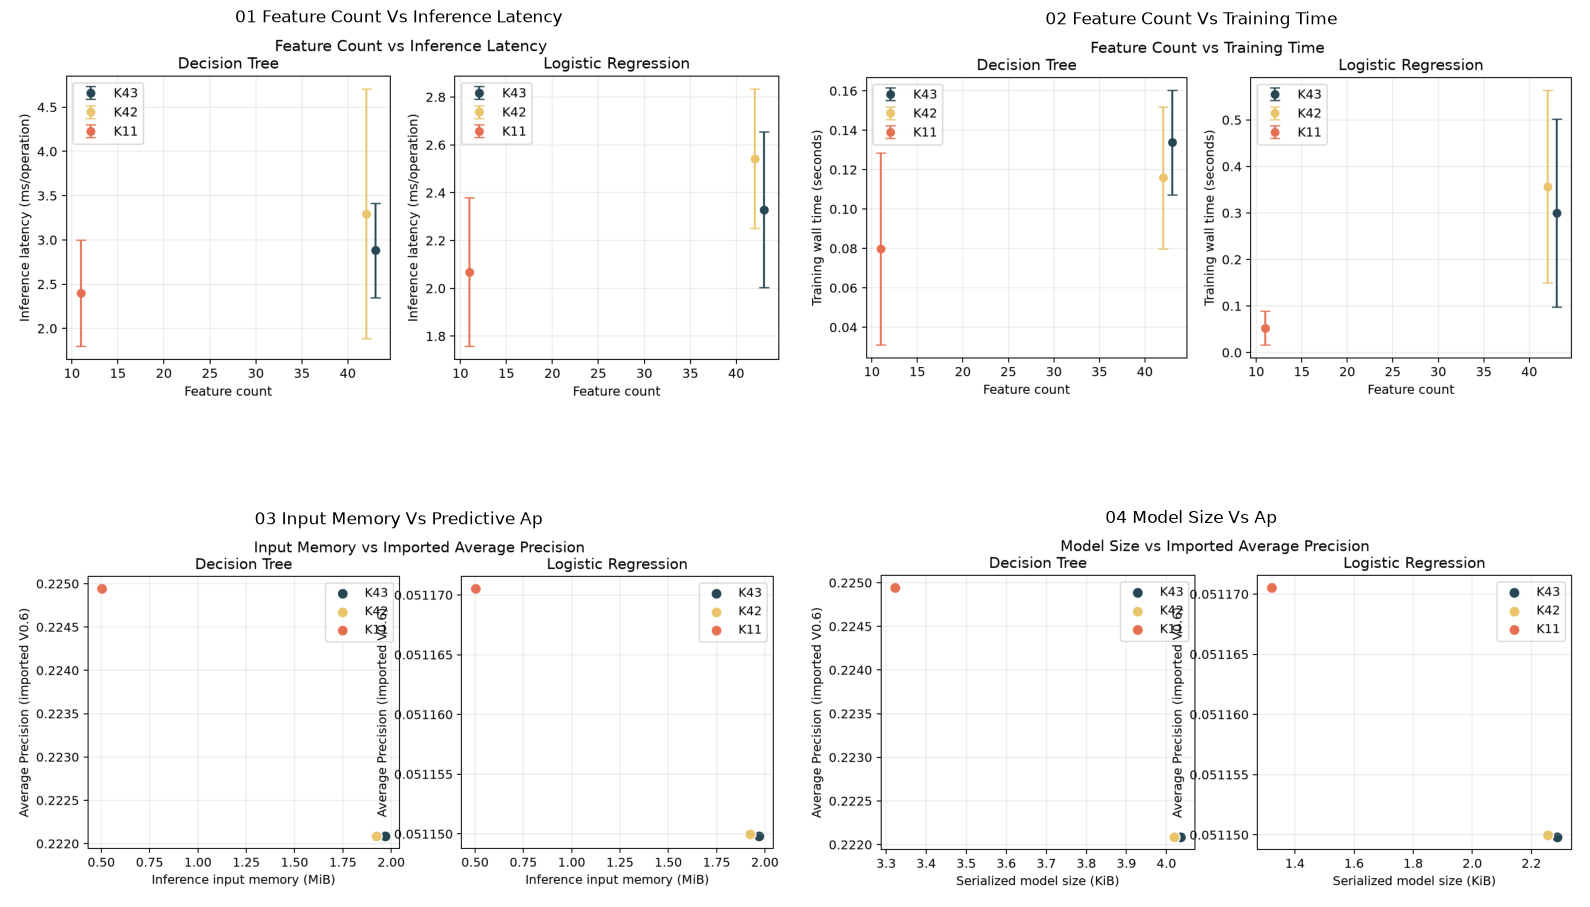

In [7]:
figure_paths = [RESULTS / 'figures' / f'{index:02d}_{name}.png' for index, name in [
    (1, 'feature_count_vs_inference_latency'),
    (2, 'feature_count_vs_training_time'),
    (3, 'input_memory_vs_predictive_ap'),
    (4, 'model_size_vs_ap'),
    (5, 'relative_computational_savings'),
    (6, 'dt_vs_lr_computational_comparison'),
    (7, 'pareto_performance_efficiency'),
    (8, 'measurement_variability_cv'),
]]
assert all(path.is_file() for path in figure_paths)
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for axis, path in zip(axes.flat, figure_paths[:4]):
    axis.imshow(plt.imread(path))
    axis.set_title(path.stem.replace('_', ' ').title())
    axis.axis('off')
plt.tight_layout()
plt.show()

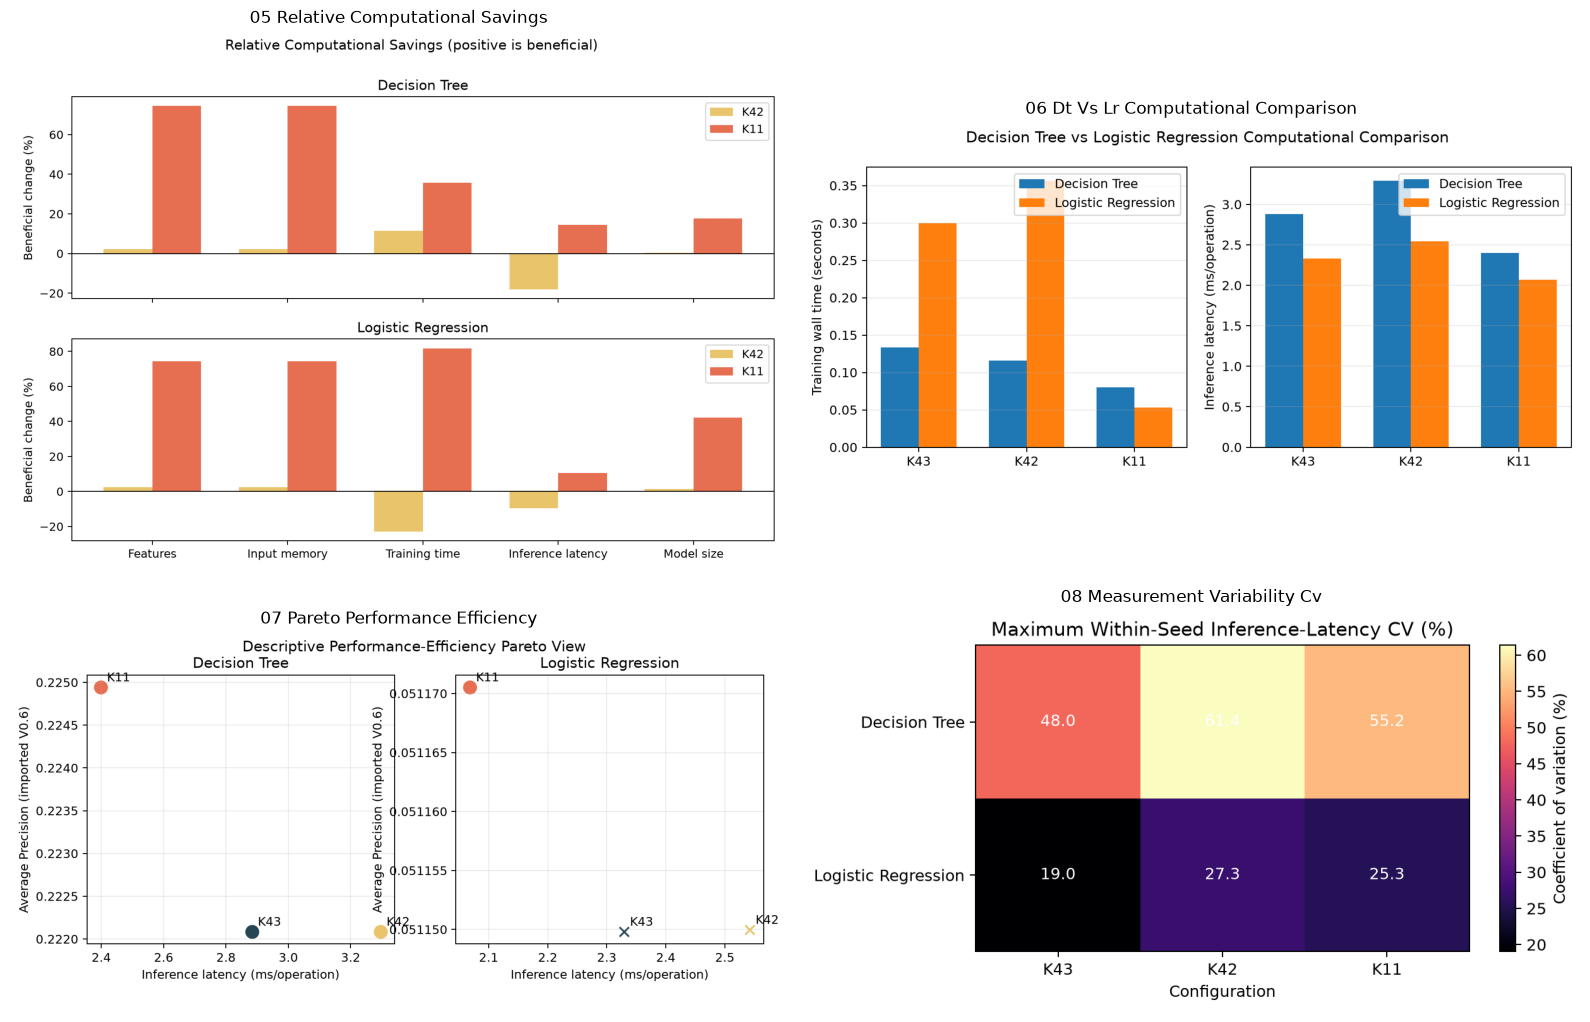

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for axis, path in zip(axes.flat, figure_paths[4:]):
    axis.imshow(plt.imread(path))
    axis.set_title(path.stem.replace('_', ' ').title())
    axis.axis('off')
plt.tight_layout()
plt.show()

## 7. Scientific interpretation

The strongest result is structural rather than temporal. MI K=11 preserves the frozen primary-scenario predictive descriptors while reducing feature count and selected-input memory by about 74.4%. It also produces clear reductions in absolute process RSS and serialized model size for both classifiers. Logistic Regression shows a clear training-time reduction, whereas Decision Tree training time and both classifiers' inference latency remain uncertain because their paired intervals cross zero and timing variability is high.

Pairwise correlation removes one feature and does not demonstrate a dependable recurring timing gain. In the unweighted descriptive Pareto view, MI K=11 is the only Logistic Regression Pareto member; all three Decision Tree configurations remain non-dominated because their predictive and noisy timing trade-offs differ. Pareto membership is descriptive and is not evidence of a completed multi-objective optimizer.

The evaluation therefore supports a lightweight-computing conclusion: substantial frozen dimensionality reduction can lower deterministic data and artifact costs while preserving the specified predictive behavior. It does **not** establish electrical-energy savings, carbon savings, statistical significance, production readiness, or generalization beyond this dataset split, controlled workload, model pair, and WSL environment.

In [9]:
mi_performance = performance.loc[performance.configuration_id == 'mutual_information_select_k_best_k11']
lr_training = mi.loc[(mi.classifier == 'logistic_regression') & (mi.phase == 'training') & (mi.metric == 'wall_time_sec')].iloc[0]
conclusions = pd.DataFrame([
    ('Completed observations', '600/600; zero failures'),
    ('Scientific sample size', '5 paired seed means'),
    ('MI K=11 feature reduction', '74.4186%'),
    ('Frozen predictive preservation', str(bool(mi_performance.predictive_performance_preserved.all()))),
    ('LR training-time saving', f"{lr_training.beneficial_change_percent:.2f}% ({lr_training.interpretation})"),
    ('Decision Tree timing', 'uncertain under paired intervals and observed variability'),
    ('Direct electrical energy', 'not measured; no backend passed preflight'),
    ('Carbon outcome', 'not reported'),
], columns=['Conclusion item', 'Evidence-based result'])
display(conclusions)
print('V0.7-F artifact-only notebook completed without rerunning experiments.')

,Conclusion item,Evidence-based result
0,Completed observations,600/600; zero failures
1,Scientific sample size,5 paired seed means
2,MI K=11 feature reduction,74.4186%
3,Frozen predictive preservation,True
4,LR training-time saving,81.81% (clear_reduction)
5,Decision Tree timing,uncertain under paired intervals and observed ...
6,Direct electrical energy,not measured; no backend passed preflight
7,Carbon outcome,not reported


V0.7-F artifact-only notebook completed without rerunning experiments.


## 8. Limitations and reproducibility

Key limitations are one fixed DataCo split, controlled rather than native cyber incidents, two CPU-only classifiers, five seeds, high timing variability, WSL virtualization, interpreter-dominated RSS, and no valid direct-energy instrument. MI K=11 also retains seed-specific feature identities.

The immutable source tables, governance audits, capability decision, protocol manifest, and eight figures are under `results/green_evaluation/`. The companion report is `docs/v07_green_evaluation_report.md`. Re-executing this notebook only re-reads and verifies these artifacts; it does not invoke V0.7 measurement or analysis pipelines.